In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np
import readgadget
import MAS_library as MASL
import Pk_library as PKL

import smoothing_library as SL

In [55]:
simidx = 0
snapshot = f'/users/odarwish/scratch/quijote/snapshots/{simidx}/snapdir_004/snap_004' #location of the snapshot
grid     = 512    #the density field will have grid^3 voxels
MAS      = 'CIC'  #Mass-assignment scheme:'NGP', 'CIC', 'TSC', 'PCS'
verbose  = True   #whether to print information about the progress
ptype    = [1]    #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read header
header   = readgadget.header(snapshot)
BoxSize  = header.boxsize/1e3  #Mpc/h
redshift = header.redshift     #redshift of the snapshot
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h

# read positions, velocities and IDs of the particles
pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h

print('BoxSize: %.3f Mpc/h'%BoxSize)
print('Redshift: %.3f'%redshift)
print('%.3f < X < %.3f'%(np.min(pos[:,0]), np.max(pos[:,0])))
print('%.3f < Y < %.3f'%(np.min(pos[:,1]), np.max(pos[:,1])))
print('%.3f < Z < %.3f'%(np.min(pos[:,2]), np.max(pos[:,2])))

BoxSize: 1000.000 Mpc/h
Redshift: 0.000
0.000 < X < 999.992
0.000 < Y < 999.992
0.000 < Z < 999.992


In [56]:
# read header
icsdir = f'/users/odarwish/scratch/quijote/snapshots/{simidx}/ICs/ics'
header_ics   = readgadget.header(icsdir)
BoxSize_ics  = header_ics.boxsize/1e3  #Mpc/h
redshift_ics = header_ics.redshift     #redshift of the snapshot
Masses_ics   = header_ics.massarr*1e10 #Masses of the particles in Msun/h

# read positions, velocities and IDs of the particles
pos_ics = readgadget.read_block(icsdir, "POS ", ptype)/1e3 #positions in Mpc/h

In [57]:
sys.path.append('/users/odarwish/nbodykit/')
import nbodykit
from nbodykit.lab import ArrayCatalog

data = {
    'Position': pos
}
catalog = ArrayCatalog(data)
catalog.attrs['BoxSize'] = BoxSize
catalog.attrs['Redshift'] = redshift
catalog.attrs['Mass'] = Masses

mesh = catalog.to_mesh(
    Nmesh=grid,           # Number of mesh cells per dimension
    resampler='cic',     # Resampling method: 'ngp', 'cic', 'tsc', 'pcs'
    compensated=True     # Apply compensation for the resampling window
)
density = mesh.compute(mode="real")

In [58]:
data = {
    'Position': pos_ics
}
catalog_ics = ArrayCatalog(data)
catalog_ics.attrs['BoxSize'] = BoxSize_ics
catalog_ics.attrs['Redshift'] = redshift_ics
catalog_ics.attrs['Mass'] = Masses_ics

mesh_ics = catalog_ics.to_mesh(
    Nmesh=grid,           # Number of mesh cells per dimension
    resampler='cic',     # Resampling method: 'ngp', 'cic', 'tsc', 'pcs'
    compensated=True     # Apply compensation for the resampling window
)
density_ics = mesh.compute(mode="real")

In [59]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)


Using CIC mass assignment scheme
Time taken = 1.612 seconds



In [60]:
delta_ics = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(pos_ics, delta_ics, BoxSize_ics, MAS, verbose=verbose)


Using CIC mass assignment scheme
Time taken = 1.495 seconds



In [61]:
# the sum of the values in all voxels should be equal to the number of particles
print('%.3f should be equal to\n%.3f'%(np.sum(delta, dtype=np.float64), pos.shape[0]))

delta *= Masses[1]
delta_ics *= Masses[1]

# now check that the mass in the density field is equal to the total mass in the simulation
print('%.3e should be equal to\n%.3e'%(np.sum(delta, dtype=np.float64), pos.shape[0]*Masses[1]))


print('%.3e should be equal to\n%.3e'%(np.sum(delta_ics, dtype=np.float64), pos_ics.shape[0]*Masses_ics[1]))

134217728.021 should be equal to
134217728.000
8.812e+19 should be equal to
8.812e+19
8.812e+19 should be equal to
8.812e+19


In [110]:
# the box is 1000 Mpc/h and every voxel has ~2 Mpc/h size. We can take ~5 slices to consider a region with a ~10 Mpc/h witdh
mean_density = np.mean(delta[:5,:,:],axis=0) #Take the first 5 component along the first axis and compute the mean value
print('Image shape:',mean_density.shape)
print('%.3e < mass < %.3e'%(np.min(mean_density), np.max(mean_density)))

# now lets consider the particles in that slide
indexes = np.where((pos[:,0]<10))
pos_slide = pos[indexes]
print('%.3f < X < %.3f'%(np.min(pos_slide[:,0]), np.max(pos_slide[:,0])))
print('%.3f < Y < %.3f'%(np.min(pos_slide[:,1]), np.max(pos_slide[:,1])))
print('%.3f < Z < %.3f'%(np.min(pos_slide[:,2]), np.max(pos_slide[:,2])))

"""
import matplotlib.pyplot as plt
from pylab import *
fig = figure(figsize=(20,10))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax2.set_aspect('equal')
ax1.imshow(mean_density.T, cmap='gnuplot',vmin=0.0, vmax=1e13, origin='lower')
ax2.scatter(pos_slide[:,1], pos_slide[:,2], s=0.001,c='r')
plt.show()
plt.clf()
"""

Image shape: (512, 512)
-2.000e+00 < mass < 2.271e+02
0.000 < X < 10.000
0.000 < Y < 999.992
0.000 < Z < 999.992


"\nimport matplotlib.pyplot as plt\nfrom pylab import *\nfig = figure(figsize=(20,10))\nax1 = fig.add_subplot(121)\nax2 = fig.add_subplot(122)\nax2.set_aspect('equal')\nax1.imshow(mean_density.T, cmap='gnuplot',vmin=0.0, vmax=1e13, origin='lower')\nax2.scatter(pos_slide[:,1], pos_slide[:,2], s=0.001,c='r')\nplt.show()\nplt.clf()\n"

In [63]:
# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

delta_ics /= np.mean(delta_ics, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('<delta> = %.3f'%np.mean(delta))
print('shape of the matrix:', delta.shape)
print('density field data type:', delta.dtype)

-2.000 < delta < 1194.511
<delta> = -1.000
shape of the matrix: (512, 512, 512)
density field data type: float32


### Let's take the power spectrum

In [64]:
import camb
from camb import model

#params_file = "/users/odarwish/scratch/quijote/fiducial/CAMB_TABLES/CAMB_params.ini"
#pars = camb.read_ini(params_file)
#results = camb.get_results(pars)

power = np.loadtxt("/users/odarwish/scratch/quijote/fiducial/CAMB_TABLES/CAMB_matterpow_0.dat").T

pars = camb.CAMBparams()

As = 2.13e-09
ns = 0.9624
Ωm = 0.3175
Ωb = 0.049
Ωc = Ωm-Ωb
h = 0.6711
σ8 = 0.834
Mν = 0.0 
fnl_loc= 0
kmax = 10.

pars.set_cosmology(H0=h*100, ombh2=Ωb*h**2, omch2=Ωc*h**2)
pars.InitPower.set_params(ns=ns, As=As)
#results = camb.get_results(pars)
pars.set_matter_power(redshifts=[0.], kmax=kmax)
pars.NonLinear = model.NonLinear_both
results = camb.get_results(pars)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh_lin, z_lin, pk_lin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

In [65]:
np.savetxt("nonlinear_power_quijote.txt", np.c_[kh_nonlin, pk_nonlin[0]])
np.savetxt("linear_power_quijote.txt", np.c_[kh_lin, pk_lin[0]])

In [66]:
from nbodykit.algorithms.fftpower import FFTPower

r = FFTPower(density, mode='1d', kmin = 1e-2)
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powern = Pk['power'].real
modesn = Pk['modes']


r = FFTPower(density_ics, mode='1d', kmin = 1e-2)
Pk_ics = r.power

# Extract k and P(k)
kn = Pk['k']
powern_ics = Pk_ics['power'].real
modesn = Pk['modes']

In [67]:
threads = int(32)
axis = 0

# compute power spectrum
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

# Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# 1D P(k)
k1D      = Pk.k1D
Pk1D     = Pk.Pk1D
Nmodes1D = Pk.Nmodes1D

# 2D P(k)
kpar     = Pk.kpar
kper     = Pk.kper
Pk2D     = Pk.Pk2D
Nmodes2D = Pk.Nmodes2D

# 3D P(k)
k       = Pk.k3D
Pk0     = Pk.Pk[:,0] #monopole
Pk2     = Pk.Pk[:,1] #quadrupole
Pk4     = Pk.Pk[:,2] #hexadecapole
Pkphase = Pk.Pkphase #power spectrum of the phases
Nmodes  = Pk.Nmodes3D


Computing power spectrum of the field...
Time to complete loop = 5.08
Time taken = 5.20 seconds


In [68]:
threads = int(64)
axis = 0

# compute power spectrum
Pk_ics = PKL.Pk(delta_ics, BoxSize, axis, MAS, threads, verbose)

# Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as
# 3D P(k)
k       = Pk_ics.k3D
Pk0_ics     = Pk_ics.Pk[:,0] #monopole


Computing power spectrum of the field...
Time to complete loop = 5.01
Time taken = 5.11 seconds


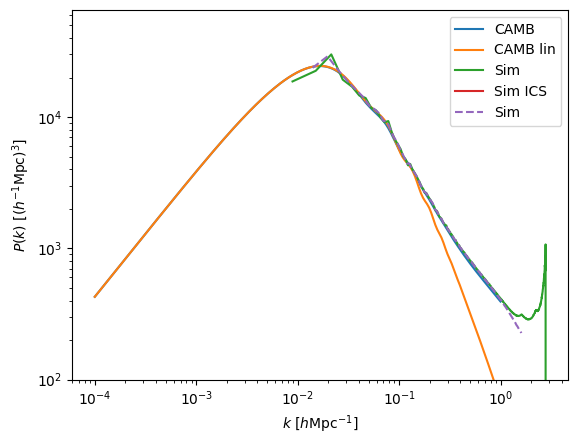

In [69]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')


plt.loglog(kh_nonlin, pk_nonlin[0], label = "CAMB")
plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin")


plt.plot(k, Pk0, label = "Sim")
plt.plot(k, Pk0_ics, label = "Sim ICS")


plt.plot(kn, powern, label = "Sim", ls = "--")


plt.legend()
plt.ylim(1e2)
plt.show()

In [70]:
import pyccl as ccl

As = 2.13e-09
ns = 0.9624
Omega_b = 0.049
Omega_c = 0.2685
h = 67.11/100
mnu = 0

cosmo = ccl.Cosmology(Omega_c = Omega_c, Omega_b = Omega_b, h = h, A_s = As, n_s = ns, m_nu = mnu)

a = 1/(1+127)
growthf = ccl.background.growth_factor(cosmo, a)

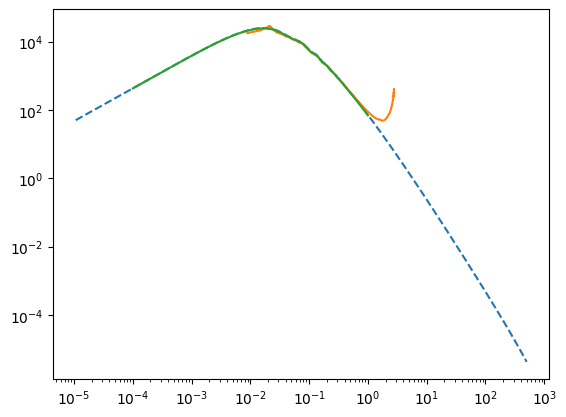

In [71]:

f_Pk   = '/users/odarwish/scratch/quijote/fiducial/CAMB_TABLES/CAMB_matterpow_0.dat'
f_norm = '/users/odarwish/scratch/quijote/fiducial/Normfac.txt'

kk, Pkk   = np.loadtxt(f_Pk, unpack=True)
Normfac = np.loadtxt(f_norm)

Pk_norm = Pkk*Normfac

plt.loglog(kk, Pk_norm, label = "Norm", ls = "--")\

camb_table = np.loadtxt("/users/odarwish/scratch/quijote/fiducial/CAMB_TABLES/CAMB_transfer_127.dat").T
k_t, t_t = camb_table[0], camb_table[1] #6
t = np.interp(k, k_t, t_t)


plt.loglog(k, Pk0_ics*growthf**-2, label = "Sim ICS")

plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin")

In [72]:
import scipy
from scipy import interpolate as interp

plinf = interp.CubicSpline(kh_lin, pk_lin[0])
pnlinf = interp.CubicSpline(kh_nonlin, pk_nonlin[0])

In [73]:
psimf = interp.CubicSpline(k, Pk0)

In [74]:
"""top_hat = lambda k, R: 3*np.sin(k*R)/(k*R)**3-3*np.cos(k*R)/(k*R)**2
gauss_filt = lambda k, R: np.exp(-k**2*R**2/2)"""

'top_hat = lambda k, R: 3*np.sin(k*R)/(k*R)**3-3*np.cos(k*R)/(k*R)**2\ngauss_filt = lambda k, R: np.exp(-k**2*R**2/2)'

In [75]:
R = 20 #h^{-1}Mpc

grid    = delta.shape[0]
#Filter  = 'Gaussian'
Filter  = 'Top-Hat-k'
threads = 64

kmin, kmax = 0.051, 0.15 #h/Mpc

# compute FFT of the filter
W_k = SL.FT_filter(BoxSize, R, grid, Filter, threads, kmin, kmax)

# smooth the field
field_smoothed = SL.field_smoothing(delta, W_k, threads)

In [76]:
# Get dimensions of the density field
dims = delta.shape[0]
middle = dims // 2

# Create a filter in k-space that is the inverse of P(k)
filter_k = np.zeros((dims, dims, middle+1), dtype=np.complex64)
kF = 2.0 * np.pi / BoxSize  # fundamental frequency

In [77]:
delta_k = PKL.FFT3Dr_f(delta, threads)

In [78]:
delta_k.shape

(512, 512, 257)

In [79]:
"""kF = 2.0 * np.pi / BoxSize
k_grid = np.zeros((dims, dims, middle+1), dtype=np.float32)
    
# Fill the k grid
for i in range(dims):
    i1 = i if i <= middle else i - dims
    for j in range(dims):
        j1 = j if j <= middle else j - dims
        for l in range(middle+1):
            k_grid[i, j, l] = kF * np.sqrt(i1**2 + j1**2 + l**2)"""

# Generate frequency arrays
kx = kF * np.fft.fftfreq(dims) * dims
ky = kF * np.fft.fftfreq(dims) * dims
kz = kF * np.fft.fftfreq(dims)[:middle+1] * dims

# Pre-allocate k_grid
k_grid_new = np.zeros((dims, dims, middle+1), dtype=np.float32)

# Calculate k-values slice by slice
for i in range(dims):
    # Create 2D meshgrid for this i value
    ky_grid, kz_grid = np.meshgrid(ky, kz, indexing='ij')
    # Calculate and store k magnitude
    k_grid_new[i] = np.sqrt(kx[i]**2 + ky_grid**2 + kz_grid**2)

In [80]:
middle        = dims//2
normalization = 0.0
R_grid        = (R*dims/BoxSize)
R2            = R_grid**2
factor = np.exp(-k_grid_new**2/(2.0*R2))

In [81]:
import numpy as np

def gaussian_filter_pythonic(BoxSize, R, dims, threads=1):
    """
    Create a Gaussian filter in Fourier space, matching Pylians3's implementation.
    
    Parameters:
    -----------
    BoxSize : float
        Size of the simulation box in Mpc/h
    R : float
        Smoothing scale in Mpc/h
    dims : int
        Number of grid cells in each dimension
    threads : int, optional
        Number of threads to use for FFT
        
    Returns:
    --------
    filter_k : 3D complex numpy array
        The Fourier transform of the Gaussian filter
    """
    middle = dims // 2
    R_grid = (R * dims / BoxSize)
    R2 = R_grid**2
    
    # Create the real-space filter
    field = np.zeros((dims, dims, dims), dtype=np.float32)
    
    # Create coordinate arrays - this is more efficient than meshgrid for this case
    x = np.arange(dims, dtype=np.int32)
    x[middle:] -= dims  # Adjust coordinates to match Pylians3 convention
    
    # Create the Gaussian filter using broadcasting
    # This replaces the triple loop in the original Cython code
    xx, yy, zz = np.meshgrid(x, x, x, indexing='ij')
    d2 = xx**2 + yy**2 + zz**2
    
    # Apply Gaussian filter formula
    field = np.exp(-d2 / (2.0 * R2)).astype(np.float32)
    
    # Normalize - this matches the normalization in the original code
    field = field / np.sum(field)
    
    # Transform to k-space using Pylians3's FFT function
    filter_k = PKL.FFT3Dr_f(field, threads)
    
    return filter_k

In [82]:
#factor = gaussian_filter_pythonic(BoxSize, R, dims, threads=1)

In [83]:
#np.allclose(factor, W_k)

In [84]:
#W_k.mean(), factor.mean()

In [85]:
import numpy as np
import numba as nb

@nb.jit(nopython=True)
def get_k_grid_fourier(BoxSize, dims):
    """
    Generate k vectors grid matching the Fourier modes from FFT3Dr_f.
    
    Parameters:
    -----------
    BoxSize : float
        Size of the simulation box in physical units
    dims : int
        Number of grid cells along each dimension
        
    Returns:
    --------
    kx, ky, kz : 3D arrays of shape (dims, dims, dims//2+1)
        Arrays containing the k-vector components for each Fourier mode
    kmag : 3D array of shape (dims, dims, dims//2+1)
        Array containing the magnitude of k for each Fourier mode
    """
    # Calculate fundamental frequency and middle index
    kF = 2.0 * np.pi / BoxSize
    middle = dims // 2
    
    # Initialize arrays for k vectors with the shape matching FFT3Dr_f output
    kx_grid = np.zeros((dims, dims, middle+1), dtype=np.float64)
    ky_grid = np.zeros((dims, dims, middle+1), dtype=np.float64)
    kz_grid = np.zeros((dims, dims, middle+1), dtype=np.float64)
    kmag_grid = np.zeros((dims, dims, middle+1), dtype=np.float64)
    
    # Fill the grid with k-vectors
    for kxx in range(dims):
        kx = kxx - dims if kxx > middle else kxx
        
        for kyy in range(dims):
            ky = kyy - dims if kyy > middle else kyy
            
            for kzz in range(middle+1):  # Only half of kz due to real-to-complex FFT
                kz = kzz - dims if kzz > middle else kzz
                
                # Store the k-vector components in physical units
                kx_grid[kxx, kyy, kzz] = kx * kF
                ky_grid[kxx, kyy, kzz] = ky * kF
                kz_grid[kxx, kyy, kzz] = kz * kF
                
                # Calculate magnitude
                kmag_grid[kxx, kyy, kzz] = np.sqrt(kx**2 + ky**2 + kz**2) * kF
    
    return kx_grid, ky_grid, kz_grid, kmag_grid

In [86]:
kx_grid, ky_grid, kz_grid, kmag_grid = get_k_grid_fourier(BoxSize, dims)
# Interpolate P(k) values
plinear_interp = plinf(kmag_grid)
pnlinear_interp = pnlinf(kmag_grid)
psimf_interp = psimf(kmag_grid)

In [87]:
kmask = (kmag_grid >= kmin) & (kmag_grid <= kmax)

In [88]:
ptot = pnlinear_interp
ptot = psimf_interp

filter_ivf = kmask*1/ptot
Fg = 5/7 #17/21
filter_wf = Fg*kmask*plinear_interp*1/ptot
field_ivf = SL.field_smoothing(delta, filter_ivf.astype(np.complex64), threads)
field_wf = SL.field_smoothing(delta, filter_wf.astype(np.complex64), threads)



filter_shift = 0.5*kmask*kx_grid*plinear_interp*1/ptot
field_shift_wf = SL.field_smoothing(delta, filter_shift.astype(np.complex64), threads)

In [89]:
threads = int(32)
axis = 0

growth = field_ivf*field_wf
shift_n = field_ivf*field_shift_wf

# compute power spectrum
Pk = PKL.Pk(growth, BoxSize, axis, MAS, threads, verbose)

# 3D P(k)
k       = Pk.k3D
Pk0growth     = Pk.Pk[:,0] #monopole
Pkphase = Pk.Pkphase #power spectrum of the phases
Nmodes  = Pk.Nmodes3D


# compute power spectrum
Pk = PKL.Pk(shift_n, BoxSize, axis, MAS, threads, verbose)

# 3D P(k)
k       = Pk.k3D
Pk0shift_n  = Pk.Pk[:,0] #monopole
Pkphase = Pk.Pkphase #power spectrum of the phases
Nmodes  = Pk.Nmodes3D


Computing power spectrum of the field...
Time to complete loop = 4.86
Time taken = 4.99 seconds

Computing power spectrum of the field...
Time to complete loop = 4.84
Time taken = 4.97 seconds


In [90]:
Pk = PKL.XPk([delta,growth], BoxSize, axis, ['CIC','CIC'], threads)
Pk_ics = PKL.XPk([delta_ics,growth], BoxSize, axis, ['CIC','CIC'], threads)

Pk0_X  = Pk.XPk[:,0,0] #monopole of 1-2 cross P(k)
Pk0_X_ics  = Pk_ics.XPk[:,0,0] #monopole of 1-2 cross P(k)


Computing power spectra of the fields...
Time FFTS = 0.35
Time loop = 3.34
Time taken = 3.71 seconds

Computing power spectra of the fields...
Time FFTS = 0.35
Time loop = 3.35
Time taken = 3.71 seconds


In [91]:
threads = 128

# compute power spectrum
Pk_ics = PKL.XPk([delta_ics,shift_n], BoxSize, axis, ['CIC','CIC'], threads)
# 3D P(k)
k       = Pk_ics.k3D
Pk0_X_shift_n_ics  = Pk_ics.Pk[:,0, 0] #monopole


Computing power spectra of the fields...
Time FFTS = 0.30
Time loop = 3.35
Time taken = 3.66 seconds


In [92]:
out = np.load("out.npy", allow_pickle = True).item()
out.keys()

key = "g"

Ks = out["Ks"]

N = out[(key, key)]**-1.

keys = ["g", "s", "t"]
bias = 0
for key_ in keys:
    invNk = out[(key, key_)]
    bias += N*invNk

Pinterp = np.interp(Ks, kh_lin, pk_lin[0])

/tmp/ipykernel_65219/281770225.py:8: RuntimeWarning: divide by zero encountered in reciprocal
  N = out[(key, key)]**-1.
/tmp/ipykernel_65219/281770225.py:14: RuntimeWarning: invalid value encountered in multiply
  bias += N*invNk


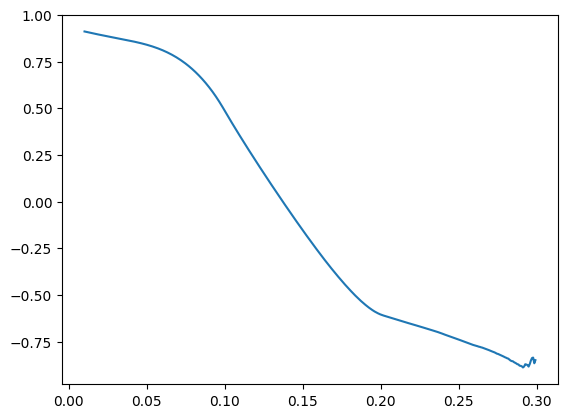

In [93]:
plt.plot(Ks, bias)

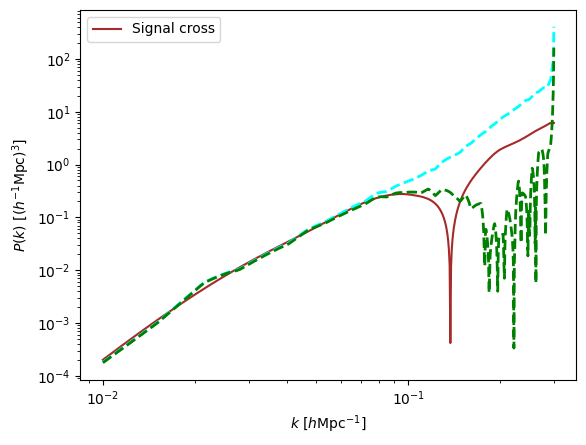

In [94]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')

fac = Ks**4
plt.plot(Ks, abs(fac*bias*Pinterp), color= "brown", label = "Signal cross")

plt.plot(Ks, abs(fac*np.interp(Ks, k, Pk0_X)*N), lw = 2, color = "cyan", ls = "--")

plt.plot(Ks, abs(fac*np.interp(Ks, k, Pk0_X_ics)*N*growthf**-1), lw = 2, color = "green", ls = "--")


#plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin", color = "black")


plt.legend()
#plt.ylim(1e2)
#plt.xlim(1e-4, 1)
plt.show()

In [95]:
from nbodykit.source.mesh.field import FieldMesh
import json

class Smoother(object):
    """
    Class to apply smoothing to field.
    """
    def __init__(self):
        raise NotImplementedError

    def get_smoothing_kernel_of_Nth_iteration(self, N):
        raise NotImplementedError


class HardSmoother(Smoother):
    """
    Apply Gaussian smoothing to field.
    """
    def __init__(
        self,
        kmin, kmax,
        name='HardSmoother'
        ):
        self.kmin = kmin
        self.kmax = kmax
        self.name = name

    def get_smoothing_kernel(self):
        kmin, kmax = self.kmin, self.kmax
        if kmin is None or kmax==0.:
            def kernel_fcn(k3vec, val):
                return val
        else:
            def kernel_fcn(k3vec, val):
                k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
                kmag = np.sqrt(k2)
                window = (kmag >= kmin) & (kmag <= kmax)
                return  window * val
        return kernel_fcn

    def apply_smoothing(self, meshsource):
        # make a copy
        out = FieldMesh(meshsource.compute(mode='complex'))
        kernel_fcn = self.get_smoothing_kernel()
        out = out.apply(kernel_fcn, kind='wavenumber', mode='complex')
        return out

    def to_dict(self):
        return dict(
            kmin=self.kmin, kmax = self.kmax, name=self.name)

    def __str__(self):
        return json.dumps(self.to_dict())

    def __repr__(self):
        return self.__str__()
    

smoother = HardSmoother(kmin, kmax)
delta_mesh = FieldMesh(density)
delta_mesh_smoothed = smoother.apply_smoothing(delta_mesh)

In [43]:
def ivf_operator(k3vec, val):
    k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    pnlinear_interp = pnlinf(kmag)
    return 1/pnlinear_interp*val

def growth_estimator(k3vec, val):
    Fg = 5/7
    k2 = np.sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    plinear_interp = plinf(kmag)
    return Fg*plinear_interp*val

def shift_estimator(k3vec, val):
    i = 0
    Fs = 0.5*k3vec[i]
    k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    plinear_interp = plinf(kmag)
    kmag[kmag == 0] = 1
    return Fs*plinear_interp*val/kmag

def new_shift_estimator(k3vec, val):
    i = 0
    Fs = 0.5*k3vec[i]
    k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    plinear_interp = plinf(kmag)
    kmag[kmag == 0] = 1
    return Fs*plinear_interp*val/kmag


out = FieldMesh(delta_mesh_smoothed.compute(mode='complex'))
delta_ivf = out.apply(ivf_operator, kind='wavenumber', mode='complex')

out = FieldMesh(delta_ivf.compute(mode='complex'))
delta_wf = out.apply(growth_estimator, kind='wavenumber', mode='complex')

out = FieldMesh(delta_ivf.compute(mode='complex'))
delta_wf_shift = out.apply(new_shift_estimator, kind='wavenumber', mode='complex')

/tmp/ipykernel_65219/231782137.py:35: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
/tmp/ipykernel_65219/2141082570.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh


In [144]:
base_field_mesh = FieldMesh(delta_ivf.compute(mode='complex'))


for idir in range(3):
    # compute Psi_i
    def Psi_i_fcn(k3vec, val, idir=idir):
        kk = np.sum(ki**2 for ki in k3vec)  # k^2 on the mesh
        kk[kk == 0] = 1
        plinear_interp = plinf(kk)
        return -1.0j * k3vec[idir] * plinear_interp * val / kk

    Psi_i_x = base_field_mesh.apply(
        Psi_i_fcn, mode='complex',
        kind='wavenumber').compute(mode='real')

    product = (Psi_i_x * base_field_mesh.compute(mode='real'))
    product = FieldMesh(product)#.compute(mode='complex')
    
    # compute nabla_i delta
    def grad_i_fcn(k3vec, val, idir=idir):
        return -1.0j * k3vec[idir] * val

    final = product.apply(
        grad_i_fcn, mode='complex',
        kind='wavenumber').compute(mode='real')

    # multiply and add up in x space
    if idir == 0:
        out_rfield = final
    else:
        out_rfield += final

/tmp/ipykernel_65219/2141082570.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
/tmp/ipykernel_65219/2128989089.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  kk = np.sum(ki**2 for ki in k3vec)  # k^2 on the mesh


In [44]:
delta_ivf_real = delta_ivf.compute(mode="real")
delta_wf_real = delta_wf.compute(mode="real")
delta_wf_shift_real = delta_wf_shift.compute(mode="real")

/tmp/ipykernel_65219/2141082570.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
/tmp/ipykernel_65219/2141082570.py:9: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
/tmp/ipykernel_65219/2141082570.py:17: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh


In [97]:
growth_nbody = delta_ivf_real*delta_wf_real
shift_nbody = delta_ivf_real*delta_wf_shift_real

from nbodykit.algorithms.fftpower import FFTPower

r = FFTPower(growth_nbody, mode='1d', kmin = 1e-2)
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powern = Pk['power'].real
modesn = Pk['modes']

r = FFTPower(growth_nbody, second = delta_mesh, mode='1d', kmin = 1e-2)
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powercrossn = Pk['power'].real
modesn = Pk['modes']

r = FFTPower(shift_nbody, second = delta_mesh, mode='1d', kmin = 1e-2)
Pks = r.power

# Extract k and P(k)
kn = Pks['k']
powercrossns = Pks['power'].real
modesn = Pks['modes']

MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796


In [ ]:
shift_nbody_new = out_rfield
r = FFTPower(shift_nbody_new, second = delta_mesh, mode='1d', kmin = 1e-2)
Pks = r.power

# Extract k and P(k)
kn = Pks['k']
powercrossns_new = Pks['power'].real
modesn = Pks['modes']

r = FFTPower(shift_nbody_new, mode='1d', kmin = 1e-2)
Pks = r.power

# Extract k and P(k)
kn = Pks['k']
powershift = Pks['power'].real
modesn = Pks['modes']

MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796


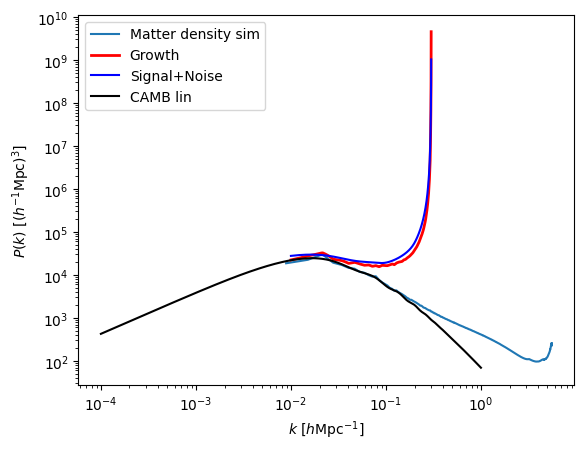

In [46]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')m
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')
plt.plot(k, Pk0, label = "Matter density sim")

plt.plot(Ks, np.interp(Ks, k, Pk0growth)*N**2, lw = 2, color = "red", label = "Growth")
plt.plot(Ks, Pinterp*bias**2+N, color= "blue", label = "Signal+Noise")
#plt.plot(Ks, N, lw = 2, color = "green", label = "Noise")
plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin", color = "black")

plt.legend()

#plt.ylim(1e2, 1e5)
#plt.xlim(1e-4, 1)
plt.show()

In [ ]:
out = np.load("out.npy", allow_pickle = True).item()
out.keys()

key = "s"

Ks = out["Ks"]

N = out[(key, key)]**-1.

keys = ["g", "s", "t"]
bias = 0
for key_ in keys:
    try:
        invNk = out[(key, key_)]
    except:
        invNk = out[(key_, key)]
    bias += N*invNk

Pinterp = np.interp(Ks, kh_lin, pk_lin[0])

In [ ]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')
plt.plot(k, Pk0, label = "Matter density sim")

plt.plot(Ks, Pinterp*bias**2+N, color= "blue", label = "Signal+Noise")
plt.plot(Ks, np.interp(Ks, knn, powershift)*N**2, lw = 2, color = "red", label = "Shift New", ls = "--")
#plt.plot(knn, powershift)
#plt.plot(Pkk['k'], Pkk['power'].real)

#plt.plot(Ks, np.interp(Ks, kn, powercrossns_new)*N, color = "orange")
#plt.plot(Ks, np.interp(Ks, k, Pk0_X_shift_n_ics)*N*growthf**-1., lw = 2, color = "green", label = "Shift New Cross", ls = "--")
#plt.plot(Ks, Pinterp*bias, color= "brown", label = "Signal")
#plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin", color = "black")

plt.legend()
#normalization_ivf, normalization_wf
#plt.ylim(1e2, 1e5)
#plt.xlim(1e-4, 1)
plt.show()